# numpy_candles package — integration test

In [1]:
import sys, os

# repo root is two levels above notebooks/tests/
repo_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

csv_path = os.path.join(repo_root, 'BTCUSDT-1m-2026-03.csv')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone

from packages.numpy_candles import (
    load_numpy_candles_from_binance_file,
    numpy_candle_test,
    numpy_candles_info,
    numpy_candles_filter_date,
    NC,
)

## Load full month

In [2]:
candles = load_numpy_candles_from_binance_file(csv_path)

In [3]:
numpy_candle_test(candles)

all tests passed


In [4]:
numpy_candles_info(candles)

shape=(44640, 11)  tf=60s  duration=44639.0min/31.00days  first=2026-03-01 00:00:00 UTC  last=2026-03-31 23:59:00 UTC


## Filter to 2026-03-03

In [5]:
day = numpy_candles_filter_date(candles, start_date='2026-03-03', end_date='2026-03-03 23:59:00')

In [6]:
numpy_candle_test(day)

all tests passed


In [7]:
numpy_candles_info(day)

shape=(1440, 11)  tf=60s  duration=1439.0min/1.00days  first=2026-03-03 00:00:00 UTC  last=2026-03-03 23:59:00 UTC


In [8]:
assert len(day) == 1440, f"Expected 1440 candles, got {len(day)}"
print(f"Candle count: {len(day)} — OK")

Candle count: 1440 — OK


## VWAP chart — 2026-03-03

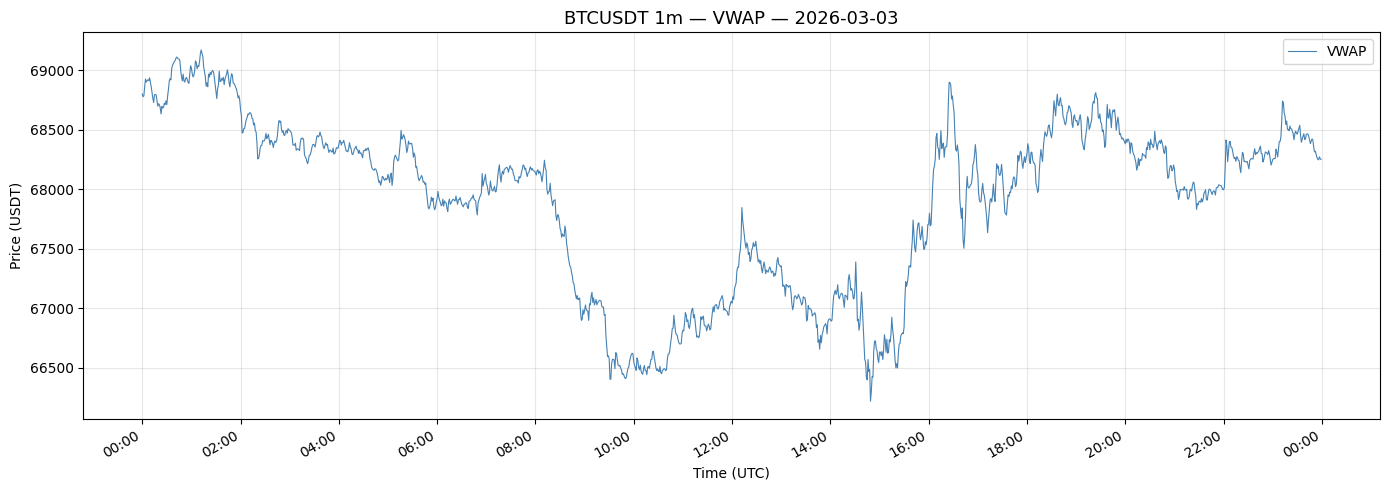

In [9]:
timestamps = [datetime.fromtimestamp(ts / 1000, tz=timezone.utc) for ts in day[:, NC.ts]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(timestamps, day[:, NC.vwap], linewidth=0.8, color='steelblue', label='VWAP')
ax.set_title('BTCUSDT 1m — VWAP — 2026-03-03', fontsize=13)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Price (USDT)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
fig.autofmt_xdate()
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()